# Custom Model: GCN-LSTM (Graph Convolutional Network + Long Short-Term Memory)

## Overview
- Trains a Graph Convolutional Network coupled with LSTM on preprocessed spatio-temporal traffic sequences
- Uses 96-step sliding windows (24 hours of 15-minute intervals) as input sequences across 40 SCATS stations
- Evaluates model performance on held-out test set and visualizes predictions versus actual values

### Key data assumptions
- Input sequences are preprocessed spatio-temporal tensors split into train/validation/test sets (96 timesteps × 40 nodes × 13 features)
- Adjacency matrix encodes spatial relationships between stations using KNN (k=4)
- Traffic volume and all temporal features are scaled to 0-1 range for model convergence
- Data is chronologically ordered with no temporal overlap between train/val/test splits

<!-- ### Pipeline outline (sections below)
1. **Setup & imports** 
2. **Define LSTM model architecture** 
3. **Load preprocessed training data** 
4. **Scale features for model input** 
5. **Confirm sequence data shape**
6. **Compile and train the LSTM model** 
7. **Visualize training performance** 
8. **Save the trained LSTM model**  -->

# 1. Setup and imports
This cell imports the packages required for model training, including:
- data handling with `pandas` and `numpy`
- graph and network utilities with `networkx` and `sklearn.neighbors.NearestNeighbors`
- plotting with `matplotlib`
- deep learning framework with `torch` and `torch.nn`
- scaling with `sklearn.preprocessing.MinMaxScaler`
- saving and loading data with `pickle`

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle
import os
from sklearn.neighbors import NearestNeighbors

# 2. Load preprocessed training data
This cell reads the preprocessed GCN-LSTM dataset saved by the preprocessing notebook. It loads:
- training, validation, and test sequences with spatio-temporal structure
- the adjacency matrix and node-to-index mapping for spatial relationships
- the long-format dataframe and feature column definitions

In [2]:
print("Loading preprocessed data...")

with open('../data/preprocessed/preprocessed_data_custom_gcn_lstm.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']

y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
df_long = data_dict['df_long']

A = data_dict['A']
node_to_idx = data_dict['node_to_idx']

print(f"Train: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Val: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test: X_test {X_test.shape}, y_test {y_test.shape}") 
print(f"Adjacency matrix shape: {A.shape}")
print(f"Number of nodes: {len(node_to_idx)}")

Loading preprocessed data...
Train: X_train (2015, 96, 40, 13), y_train (2015, 40)
Val: X_val (433, 96, 40, 13), y_val (433, 40)
Test: X_test (432, 96, 40, 13), y_test (432, 40)
Adjacency matrix shape: (40, 40)
Number of nodes: 40


- Training shapes: X_train (samples × 96 timesteps × 40 nodes × 13 features), y_train (samples × 40 nodes)
- Validation shapes: X_val (samples × 96 × 40 × 13), y_val (samples × 40)
- Test shapes: X_test (samples × 96 × 40 × 13), y_test (samples × 40)
- Adjacency matrix: (40 × 40) encoding spatial relationships between stations
- Number of SCATS stations: 40 

# 3. Build adjacency, normalize data, and define features 
The cells below prepare the spatio-temporal input for training by:
- constructing the KNN-based adjacency matrix for the SCATS sensor network
- defining the complete feature set, including the target traffic volume and temporal/lag features
- applying separate MinMax scaling to the target and the input features to ensure stable model convergence

Building Adjacency Matrix using KNN algorithm...
   => Spatial structure: 40 SCATS stations

   => Opening spatial graph visualization map...


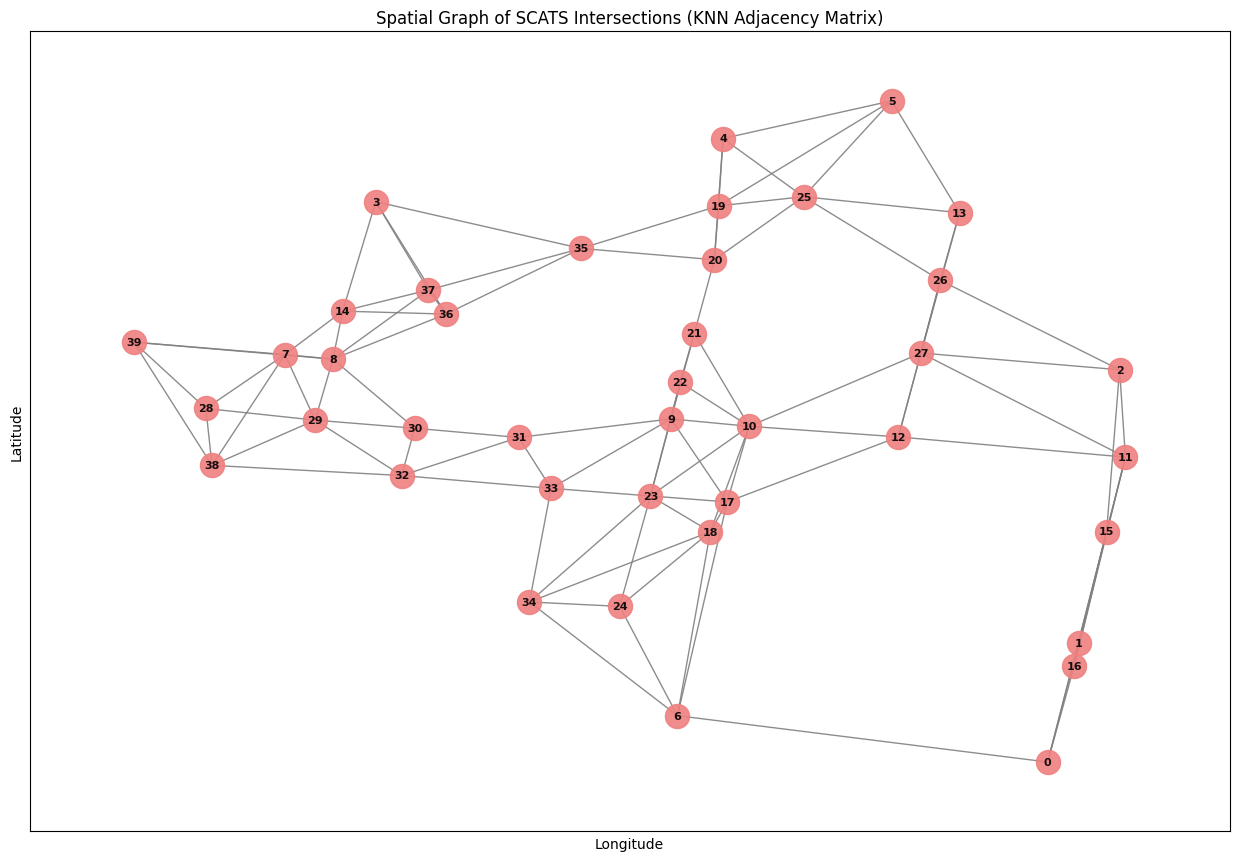

In [14]:
from gcn_lstm_core.gcn_lstm_preprocessing_functions import build_adjacency_matrix, visualize_spatial_graph

print("Building Adjacency Matrix using KNN algorithm...")
A, node_to_idx = build_adjacency_matrix(df_long, k=4)
num_nodes = len(node_to_idx)
print(f"   => Spatial structure: {num_nodes} SCATS stations")

visualize_spatial_graph(A, node_to_idx, df_long)

# Column 0 in tensor = Traffic_Volume (target); other columns = features X
feature_cols = [
        "Traffic_Volume",
        "hour_sin",
        "hour_cos",
        "slot_sin",
        "slot_cos",
        "dow_sin",
        "dow_cos",
        "is_weekend",
        "is_rush_hour",
        "is_night",
        "traffic_lag_1",
        "traffic_lag_4",
        "traffic_lag_96",
]
x_feature_cols = [c for c in feature_cols if c != "Traffic_Volume"]
num_features = len(feature_cols)

The KNN (k=4) adjacency matrix ensures all 40 SCATS nodes are connected with no isolated stations, providing full spatial coverage for GCN message passing.

In [4]:
print("Normalization: scaler_y (Traffic_Volume) and scaler_X (features) separated")
scaler_y = MinMaxScaler(feature_range=(0, 1))
scaler_x = MinMaxScaler(feature_range=(0, 1))

df_long["Traffic_Volume_Original"] = df_long["Traffic_Volume"].copy()

scaler_y.fit(df_long[["Traffic_Volume"]])
df_long["Traffic_Volume"] = scaler_y.transform(df_long[["Traffic_Volume"]]).ravel()

scaler_x.fit(df_long[x_feature_cols])
df_long[x_feature_cols] = scaler_x.transform(df_long[x_feature_cols])

Normalization: scaler_y (Traffic_Volume) and scaler_X (features) separated


Allowing clean inverse transformation of predictions back to original traffic volume scale without interference from the feature scaling.

# 4. Build Tensor structure
This cell converts the normalized long-format SCATS data into a spatio-temporal tensor with dimensions (Time, Nodes, Features), then cuts sliding windows and splits the resulting sequences into train/validation/test sets.

In [6]:
from gcn_lstm_core.gcn_lstm_preprocessing_functions import build_tensor

print("Creating Spatio-Temporal Tensor structure (T, N, F)...")
tensor = build_tensor(df_long, node_to_idx, feature_cols)
print(f"   => Tensor dimensions (Time(T), Nodes(N), Features(F)): {tensor.shape}")

Creating Spatio-Temporal Tensor structure (T, N, F)...
   => Tensor dimensions (Time(T), Nodes(N), Features(F)): (2976, 40, 13)


Successfully built the (2976, 40, 13) spatio-temporal tensor, the data is ready for sliding window processing.

# 5. Sequence creation and train/val/test split
The cells below build the sliding-window sequence dataset, splits the data chronologically into training, validation, and test sets.

In [7]:
from gcn_lstm_core.gcn_lstm_preprocessing_functions import create_st_sequences

seq_length = 96
print(f"Cutting Sliding Window (Seq = {seq_length})...")
X, y = create_st_sequences(tensor, seq_len=seq_length)

Cutting Sliding Window (Seq = 96)...


In [8]:
print("Splitting Train/Val/Test sets chronologically (70-15-15)...")
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size :], y[train_size + val_size :]

Splitting Train/Val/Test sets chronologically (70-15-15)...


# 6. Model Training Setup
This cell prepares the model for training by:
- Initializing the GCN-LSTM model with the adjacency matrix and hyperparameters
- Setting up the PyTorch device (GPU if available, otherwise CPU)
- Configuring the Adam optimizer and MSE loss function
- Converting training and validation data to PyTorch tensors for GPU acceleration

In [9]:
from gcn_lstm_core.gcn_lstm_classes import GCN_LSTM

print("PyTorch Setup (Device, Optimizer, Data Loaders)")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   => Training deployment device: {device}")

hidden_dim = 64
lstm_hidden = 128
dropout_p = 0.35
model = GCN_LSTM(
        A,
        num_nodes=num_nodes,
        in_features=num_features,
        hidden_dim=hidden_dim,
        lstm_hidden=lstm_hidden,
        lstm_num_layers=2,
        dropout_p=dropout_p,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

PyTorch Setup (Device, Optimizer, Data Loaders)
   => Training deployment device: cpu


# 7. Start the training loop (with Early Stopping)
This cell executes the complete training workflow by:
- Creating a DataLoader for mini-batch training with batch size 32
- Iterating for up to 50 epochs, performing forward pass, backpropagation, and parameter updates on each batch
- Evaluating validation loss after each epoch to monitor model generalization
- Implementing early stopping with patience=8 (stop if no improvement for 8 consecutive epochs)
- Tracking training and validation losses throughout the training process
- Restoring the model weights from the epoch with the best validation loss

In [10]:
from gcn_lstm_core.gcn_lstm_classes import EarlyStopping

epochs = 50
print(f"Starting training loop {epochs} Epochs with integrated Early Stopping...")

batch_size = 32
train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []

early_stopper = EarlyStopping(patience=8, min_delta=0.0001)

# Only predict 1 location (1 node) but still use GCN to get information from neighboring nodes (KNN k-hop).
# You can change this index if you want to forecast a different station.
target_node_idx = 0
if target_node_idx >= num_nodes:
    raise ValueError(f"target_node_idx={target_node_idx} exceeds num_nodes={num_nodes}")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_x, target_idx=target_node_idx)  # (batch,)
            target = batch_y[:, target_node_idx]  # (batch,)
            loss = loss_fn(pred, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    epoch_train_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
            val_pred = model(X_val_t, target_idx=target_node_idx)  # (val_batch,)
            val_target = y_val_t[:, target_node_idx]  # (val_batch,)
            epoch_val_loss = loss_fn(val_pred, val_target).item()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
            f"   ► Epoch {epoch+1:02d}/{epochs} | Train Loss (MSE): {epoch_train_loss:.4f} | "
            f"Validation Loss (MSE): {epoch_val_loss:.4f}"
        )

    early_stopper(epoch_val_loss, model)
    if early_stopper.early_stop:
            print(f"   => Early Stopping stopped training at Epoch {epoch+1}.")
            break

    model.load_state_dict(early_stopper.best_state)
    print("   => Restoring Best Weights from model history.")

Starting training loop 50 Epochs with integrated Early Stopping...
   ► Epoch 01/50 | Train Loss (MSE): 0.0531 | Validation Loss (MSE): 0.2011
   => Restoring Best Weights from model history.
   ► Epoch 02/50 | Train Loss (MSE): 0.0447 | Validation Loss (MSE): 0.0099
   => Restoring Best Weights from model history.
   ► Epoch 03/50 | Train Loss (MSE): 0.0182 | Validation Loss (MSE): 0.0089
   => Restoring Best Weights from model history.
   ► Epoch 04/50 | Train Loss (MSE): 0.0149 | Validation Loss (MSE): 0.0078
   => Restoring Best Weights from model history.
   ► Epoch 05/50 | Train Loss (MSE): 0.0123 | Validation Loss (MSE): 0.0076
   => Restoring Best Weights from model history.
   ► Epoch 06/50 | Train Loss (MSE): 0.0111 | Validation Loss (MSE): 0.0187
   => Restoring Best Weights from model history.
   ► Epoch 07/50 | Train Loss (MSE): 0.0109 | Validation Loss (MSE): 0.0118
   => Restoring Best Weights from model history.
   ► Epoch 08/50 | Train Loss (MSE): 0.0115 | Validation L

- Training loss dropped sharply from 0.0531 to ~0.0094 within the first 12 epochs, indicating the model learned the traffic patterns quickly and efficiently.
- Validation loss is volatile across epochs (oscillating between 0.0062 and 0.0201) rather than steadily decreasing, suggesting some instability — possibly due to the small batch size or learning rate being slightly too high.
- Early stopping triggered at epoch 17, preventing overfitting and restoring the best weights.

# 8. Visualizing the Training Curve and Test Set Evaluation
This section visualizes the training performance and evaluates the model by:
- Plotting training and validation loss curves across all epochs to assess generalization
- Computing test set MSE and RMSE metrics on the original traffic volume scale
- Generating a forecast visualization comparing predicted values against ground truth on the test set
- Displaying predictions for the first 500 time steps to inspect model behavior in detail

Drawing Training Curve (Learning Curve)...


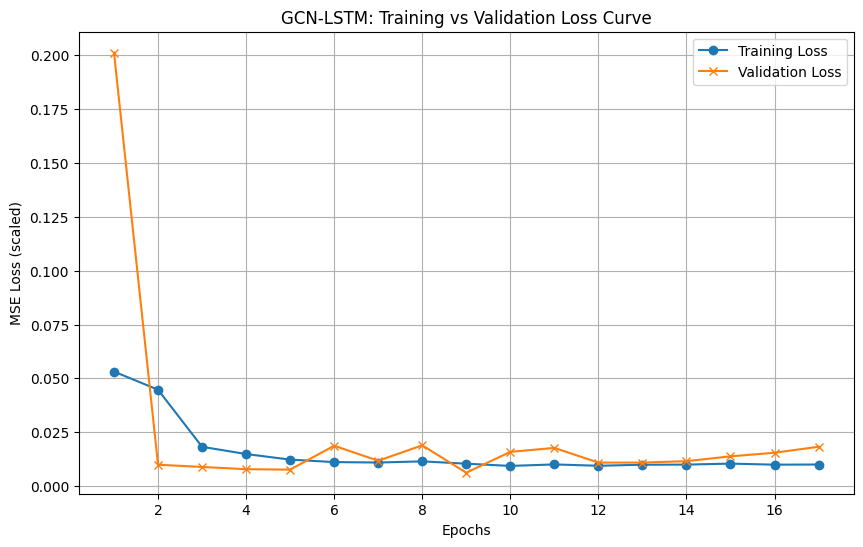

In [11]:
print("Drawing Training Curve (Learning Curve)...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", marker="o")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker="x")
plt.title("GCN-LSTM: Training vs Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss (scaled)")
plt.legend()
plt.grid()
plt.show()

- Both losses converge rapidly within the first 2 epochs, with validation loss plummeting from 0.20 to ~0.01, demonstrating the GCN-LSTM learned the underlying traffic patterns very quickly.
- After epoch 2, training loss stabilizes smoothly near ~0.01 while validation loss fluctuates slightly above it.
- Early stopping at epoch 17 was appropriate, training and validation loss had already flattened out with no meaningful improvement, meaning extra epochs would only waste computation and risk making the model less accurate.

Evaluation with Test Set & Forecasting Visualization...
   => Test MSE (original scale — vehicles/15 minutes) @ node 0: 30027.0367
   => Test RMSE (original scale — vehicles/15 minutes) @ node 0: 173.2831


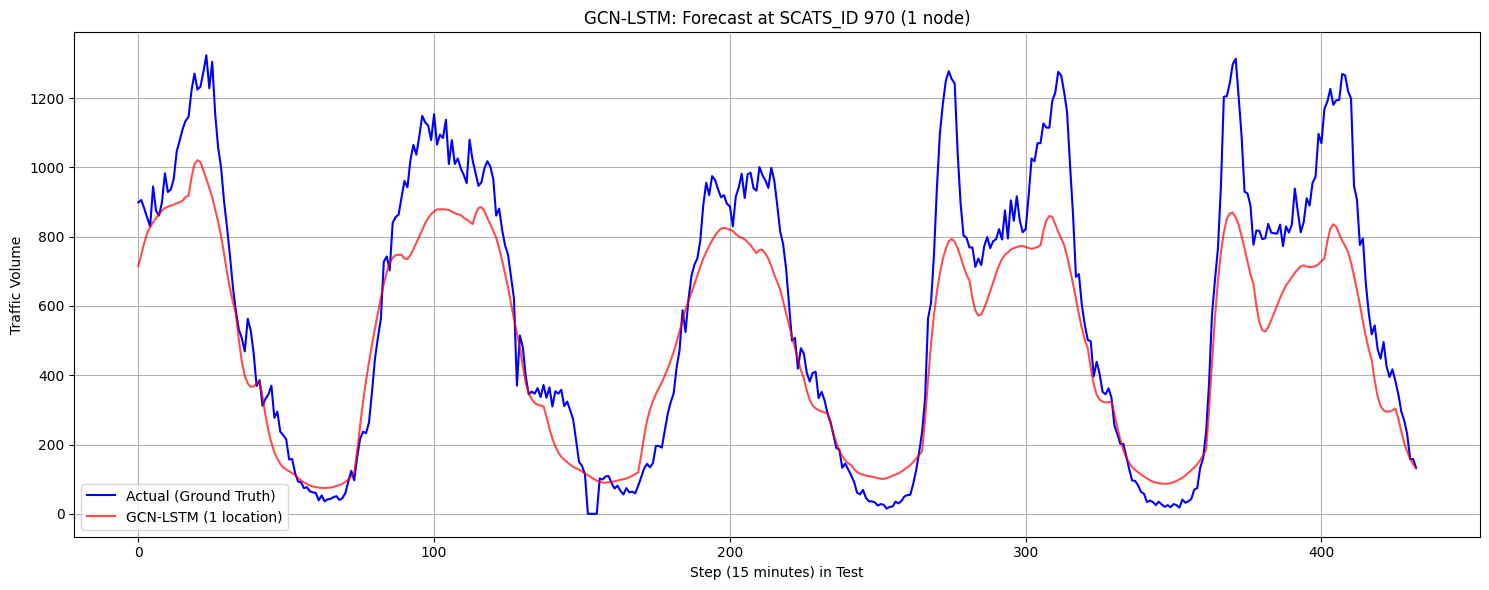

In [12]:
print("Evaluation with Test Set & Forecasting Visualization...")
model.eval()
with torch.no_grad():
        test_pred_scaled = model(
            torch.tensor(X_test, dtype=torch.float32).to(device),
            target_idx=target_node_idx,
        ).cpu().numpy()  # (samples,)

y_test_target_scaled = y_test[:, target_node_idx]  # (samples,)

y_test_denorm = scaler_y.inverse_transform(y_test_target_scaled.reshape(-1, 1)).flatten()
test_pred_denorm = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

test_mse = np.mean((y_test_denorm - test_pred_denorm) ** 2)
test_rmse = np.sqrt(test_mse)
print(f"   => Test MSE (original scale — vehicles/15 minutes) @ node {target_node_idx}: {test_mse:.4f}")
print(f"   => Test RMSE (original scale — vehicles/15 minutes) @ node {target_node_idx}: {test_rmse:.4f}")

nodes_list = list(node_to_idx.keys())
node_id = nodes_list[target_node_idx]

plt.figure(figsize=(15, 6))
plt.plot(y_test_denorm[:500], label="Actual (Ground Truth)", color="blue")
plt.plot(test_pred_denorm[:500], label="GCN-LSTM (1 location)", color="red", alpha=0.7)
plt.title(f"GCN-LSTM: Forecast at SCATS_ID {node_id} (1 node)")
plt.xlabel("Step (15 minutes) in Test")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

- The model handles low-traffic periods (troughs near 0–100) reasonably well, with predictions closely matching the actual lows, meaning it is more reliable during off-peak hours than during busy periods.
- An RMSE of 173.28 vehicles/15 minutes means the model is off by roughly 173 vehicles per 15-minute window on average — this is a notable error at a busy intersection like SCATS_ID 970 where volumes regularly exceed 1000.
- The repeating wave pattern in the predictions aligns well with the actual data's periodicity, confirming the GCN-LSTM has effectively learned the temporal structure of traffic flow at this SCATS station.

# 9. Save the trained GCN-LSTM model

In [13]:
torch.save(model.state_dict(), '../models/custom_gcn_lstm/custom_gcn_lstm_model.pth')
print("GCN-LSTM model saved successfully!")

GCN-LSTM model saved successfully!
